# 19 — Évaluation end-to-end automatique du RAG

Ce notebook évalue la dernière version complète du système sur des cas frais du **holdout validation**. Le split `test` reste verrouillé. Aucune annotation humaine n'est demandée.

Le benchmark contient **32 cas** : 21 réponses réellement générées et jugées avec OpenAI, plus 11 abstentions déterministes. Le coût est bloqué avant tout appel s'il peut dépasser **0,19 $**.

## Protocole

1. Exclure tous les exemples déjà utilisés par les anciens canaries.
2. Échantillonner les quatre domaines et les actions `answer`, `ask_followup` et `abstain`.
3. Exécuter le contrat complet : décision → preuves → génération → citations.
4. Vérifier localement le schéma JSON et l'existence exacte des citations.
5. Utiliser un juge automatique structuré pour correctness, faithfulness et complétude.
6. Appliquer les quality gates de production sans ouvrir le split test.

In [1]:
%pip install -q "openai>=1.99,<3" "python-dotenv>=1,<2" "jsonschema>=4,<5" "tiktoken>=0.7,<1" "numpy>=1.26,<3" "pandas>=2,<3" "matplotlib>=3.8,<4"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'configs' / 'automated_end_to_end_evaluation.json').exists():
            return candidate
    raise FileNotFoundError('Racine du projet introuvable.')

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'automated_end_to_end_evaluation.json'
SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'run_automated_end_to_end_evaluation.py'
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))

print('Projet       :', PROJECT_ROOT)
print('Contrat final:', config['generation_contract_experiment_id'])
print('Plafond coût : $', config['pricing']['maximum_authorized_cost_usd'], sep='')
print('Split test   : verrouillé')

Projet       : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Contrat final: planned_generation_contract_v1_b3943d6aab
Plafond coût : $0.19
Split test   : verrouillé


## 1. Dry-run obligatoire

Cette cellule sélectionne les cas, calcule le coût maximal et s'arrête sans appeler OpenAI si le plafond est dépassé.

In [3]:
dry_run = subprocess.run(
    [sys.executable, str(SCRIPT_PATH)],
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
)
print(dry_run.stdout)
if dry_run.stderr:
    print(dry_run.stderr)
dry_run.check_returncode()

Mode: DRY-RUN
Cas totaux: 32
Générations OpenAI: 21
Abstentions déterministes: 11
Coût maximal estimé: $0.170313
Plafond autorisé: $0.19
Dry-run terminé: aucun appel OpenAI.



## 2. Exécution end-to-end

Cette cellule effectue les appels manquants. Les réponses sont mises en cache : relancer `Run All` ne repaie pas les appels déjà terminés.

In [4]:
ceiling = config['pricing']['maximum_authorized_cost_usd']
execution = subprocess.run(
    [
        sys.executable,
        str(SCRIPT_PATH),
        '--execute',
        '--confirm-maximum-cost-usd',
        str(ceiling),
    ],
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
)
print(execution.stdout)
if execution.stderr:
    print(execution.stderr)
execution.check_returncode()

Mode: EXECUTE
Cas totaux: 32
Générations OpenAI: 21
Abstentions déterministes: 11
Coût maximal estimé: $0.170313
Plafond autorisé: $0.19
[01/21] eval_a9e2a0999511e0c47a958804: FAIL
[02/21] eval_47110720181195615dc25ef1: PASS
[03/21] eval_a564f9c5ee55cee79c84171b: PASS
[04/21] eval_abeeb15788aacac3475c9aed: FAIL
[05/21] eval_9a6c15d3b74803e7b408fa2c: PASS
[06/21] eval_3abcafa006763e8f74aef759: FAIL
[07/21] eval_0a77282b57d702412ac24d84: PASS
[08/21] eval_3c5ba21663e066c0d1e195e3: FAIL
[09/21] eval_8cd35f387b0f77827676dc7c: FAIL
[10/21] eval_3afa6c49c2611b719f2ca563: FAIL
[11/21] eval_3b68a8dc60d9566f50fc09eb: FAIL
[12/21] eval_4e0815393fa371707d8b1611: PASS
[13/21] eval_323ee9bd500e370e8c4b196f: FAIL
[14/21] eval_9d7a141ec0532cc62268d73d: FAIL
[15/21] eval_d8ca6f146c591c223788db14: FAIL
[16/21] eval_eabb21c8427dd51e7ef41812: FAIL
[17/21] eval_5a14180f34774eb72779b71d: PASS
[18/21] eval_ead8e695383ef7440a3b314f: PASS
[19/21] eval_dbd07f01046f74198d4b7412: PASS
[20/21] eval_979679a8a5560b

## 3. Résultats et décision

In [5]:
latest_path = (
    PROJECT_ROOT
    / 'reports'
    / 'generated'
    / 'multidoc2dial_v1'
    / 'automated_end_to_end_evaluation'
    / 'latest.json'
)
latest = json.loads(latest_path.read_text(encoding='utf-8'))
report_path = PROJECT_ROOT / latest['report_path']
report = json.loads(report_path.read_text(encoding='utf-8'))
metrics = report['metrics']

summary = pd.DataFrame([
    ('Action accuracy', metrics['action_accuracy'], config['quality_gates']['minimum_action_accuracy']),
    ('Overall pass', metrics['overall_pass_rate'], config['quality_gates']['minimum_overall_pass_rate']),
    ('JSON valide', metrics['contract_valid_rate'], config['quality_gates']['minimum_contract_valid_rate']),
    ('Citations valides', metrics['citation_valid_rate'], config['quality_gates']['minimum_citation_valid_rate']),
    ('Faithfulness', metrics['faithfulness_pass_rate'], config['quality_gates']['minimum_faithfulness_pass_rate']),
    ('Correctness acceptable', metrics['correctness_acceptable_rate'], config['quality_gates']['minimum_correctness_acceptable_rate']),
    ('Complétude', metrics['completeness_pass_rate'], config['quality_gates']['minimum_completeness_pass_rate']),
], columns=['Métrique', 'Résultat', 'Cible'])
summary['Statut'] = summary.apply(lambda row: 'PASS' if row['Résultat'] >= row['Cible'] else 'FAIL', axis=1)
summary['Résultat'] = summary['Résultat'].map(lambda value: f'{value:.2%}')
summary['Cible'] = summary['Cible'].map(lambda value: f'{value:.2%}')
display(summary)

decision = 'PASS — prêt pour l’évaluation test unique' if report['gates_passed'] else 'FAIL — le split test reste verrouillé'
display(Markdown(
    f"### Décision : {decision}\n\n"
    f"- Coût réel : **${report['cost']['actual_usd']:.6f}**\n"
    f"- Correctness moyenne : **{metrics['correctness_mean_0_to_4']:.2f}/4**\n"
    f"- Hallucinations : **{metrics['hallucination_rate']:.2%}**\n"
    f"- Rapport : `{report_path}`"
))

,Métrique,Résultat,Cible,Statut
0,Action accuracy,68.75%,85.00%,FAIL
1,Overall pass,59.38%,80.00%,FAIL
2,JSON valide,100.00%,100.00%,PASS
3,Citations valides,95.24%,95.00%,PASS
4,Faithfulness,95.24%,95.00%,PASS
5,Correctness acceptable,57.14%,80.00%,FAIL
6,Complétude,52.38%,80.00%,FAIL


### Décision : FAIL — le split test reste verrouillé

- Coût réel : **$0.071078**
- Correctness moyenne : **2.67/4**
- Hallucinations : **4.76%**
- Rapport : `C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\automated_end_to_end_evaluation_experiments\automated_end_to_end_evaluation_v1_b511270623\automated_end_to_end_evaluation_report.json`

,Domaine,examples,action_accuracy,overall_pass_rate
0,dmv,9.000000,77.78%,66.67%
1,ssa,7.000000,85.71%,71.43%
2,va,8.000000,62.50%,50.00%
3,studentaid,8.000000,50.00%,50.00%


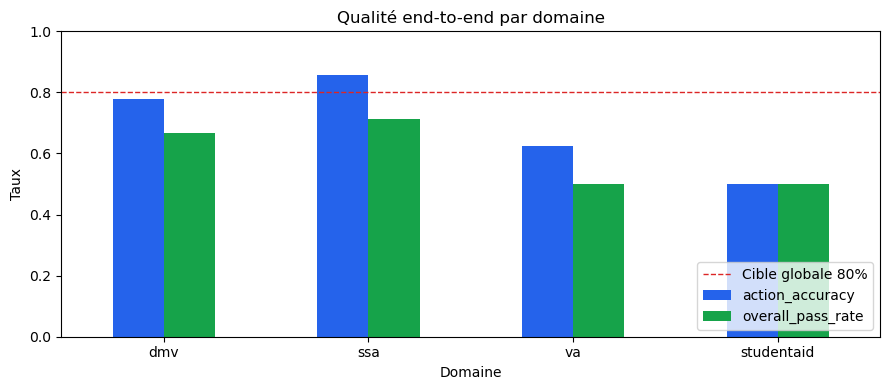

In [6]:
domain_df = (
    pd.DataFrame(report['metrics_by_domain'])
    .T
    .reset_index(names='Domaine')
)
display(domain_df.style.format({
    'action_accuracy': '{:.2%}',
    'overall_pass_rate': '{:.2%}',
}))

ax = domain_df.set_index('Domaine')[['action_accuracy', 'overall_pass_rate']].plot(
    kind='bar', figsize=(9, 4), ylim=(0, 1), rot=0, color=['#2563eb', '#16a34a']
)
ax.axhline(0.80, color='#dc2626', linestyle='--', linewidth=1, label='Cible globale 80%')
ax.set_ylabel('Taux')
ax.set_title('Qualité end-to-end par domaine')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [7]:
failed = [row for row in report['cases'] if not row['overall_pass']]
failure_table = pd.DataFrame([
    {
        'example_id': row['example_id'],
        'domain': row['domain'],
        'type': row['case_type'],
        'action_ok': row['action_correct'],
        'correctness': row['correctness_0_to_4'],
        'faithfulness': row['faithfulness_pass'],
        'completeness': row['completeness_pass'],
        'raison': (row.get('judge') or {}).get('short_reason', ''),
    }
    for row in failed
])
print(f'Échecs automatiques : {len(failed)}/{len(report["cases"])}')
display(failure_table)
print('Quand Run All est terminé, envoie-moi simplement : fait')

Échecs automatiques : 13/32


,example_id,domain,type,action_ok,correctness,faithfulness,completeness,raison
0,eval_a9e2a0999511e0c47a958804,dmv,generated,False,1,True,False,"The expected action was to abstain, but the ca..."
1,eval_abeeb15788aacac3475c9aed,va,generated,False,2,True,False,The candidate is faithful to the cited evidenc...
2,eval_3abcafa006763e8f74aef759,ssa,generated,True,3,True,False,"The candidate asks a relevant follow-up, but i..."
3,eval_3c5ba21663e066c0d1e195e3,ssa,generated,False,0,True,False,"The candidate gives the opposite answer, sayin..."
4,eval_8cd35f387b0f77827676dc7c,va,generated,False,1,True,False,The user already answered the eligibility ques...
5,eval_3afa6c49c2611b719f2ca563,studentaid,generated,False,1,False,False,The reference answer says the user does not qu...
6,eval_3b68a8dc60d9566f50fc09eb,dmv,generated,True,2,True,False,The answer is partially correct: it gives the ...
7,eval_323ee9bd500e370e8c4b196f,studentaid,generated,False,1,True,False,The candidate gives general consolidation elig...
8,eval_9d7a141ec0532cc62268d73d,studentaid,generated,False,2,True,False,The candidate gives a broadly related yes/no r...
9,eval_d8ca6f146c591c223788db14,va,generated,False,2,True,False,The answer is supported by the cited evidence ...


Quand Run All est terminé, envoie-moi simplement : fait
